In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df=pd.read_csv("../data/new_cleaned_sales_data.csv",encoding="latin1",parse_dates=["ORDERDATE"])
df.head()


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,CALCULATED_PRICE,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH,...,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,STATE,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10425,11,43.83,482.13,6,556.86015,2005-05-31,In Process,2,5,...,LA ROCHELLE GIFTS,40.67.8555,"67, rue des Cinquante Otages",Nantes,NaN,44000,France,Labrune,Janine,Small
1,10407,6,90.19,541.14,3,625.01670,2005-04-22,On Hold,2,4,...,THE SHARP GIFTS WAREHOUSE,4085553659,3086 Ingle Ln.,San Jose,CA,94217,USA,Frick,Sue,Small
2,10408,15,36.93,553.95,1,639.81225,2005-04-22,Shipped,2,4,...,"TOKYO COLLECTABLES, LTD",+81 3 3584 0555,2-2-8 Roppongi,Minato-ku,Tokyo,106-0032,Japan,Shimamura,Akiko,Small
3,10280,20,28.88,577.60,12,667.12800,2004-08-17,Shipped,3,8,...,AMICA MODELS & CO.,011-4988555,Via Monte Bianco 34,Torino,NaN,10100,Italy,Accorti,Paolo,Small
4,10419,15,42.67,640.05,7,739.25775,2005-05-17,Shipped,2,5,...,SALZBURG COLLECTABLES,6562-9555,Geislweg 14,Salzburg,NaN,5020,Austria,Pipps,Georg,Small


In [21]:
df.dtypes

ORDERNUMBER                  int64
QUANTITYORDERED              int64
PRICEEACH                  float64
CALCULATED_PRICE           float64
ORDERLINENUMBER              int64
SALES                      float64
ORDERDATE           datetime64[ns]
STATUS                      object
QTR_ID                       int64
MONTH                        int64
YEAR                         int64
PRODUCTLINE                 object
MSRP                         int64
PRODUCTCODE                 object
CUSTOMERNAME                object
PHONE                       object
ADDRESSLINE1                object
CITY                        object
STATE                       object
POSTALCODE                  object
COUNTRY                     object
CONTACTLASTNAME             object
CONTACTFIRSTNAME            object
DEALSIZE                    object
dtype: object

In [77]:
sns.reset_defaults()

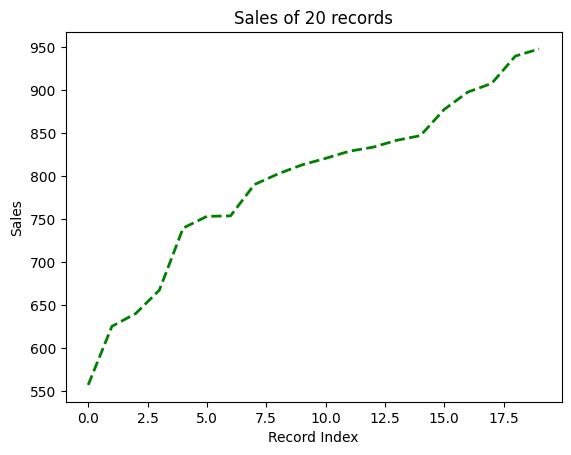

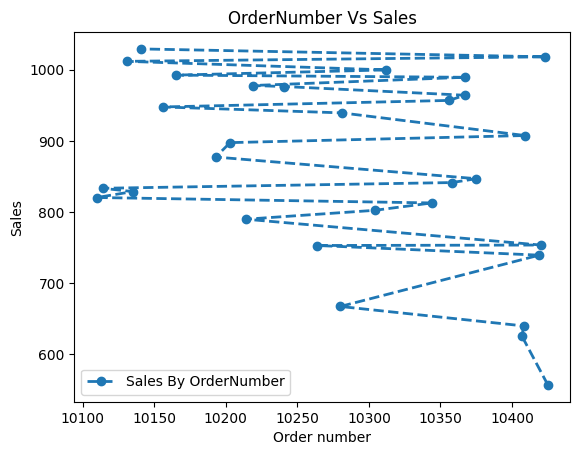

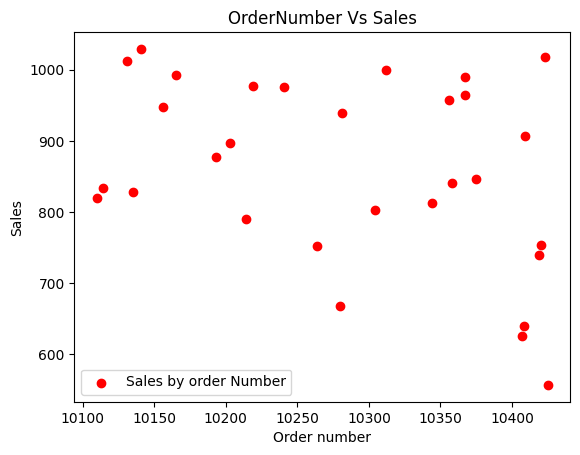

In [78]:
#Basic Sales Visualization
#Display sales of first 20 records uing Line plot
sales=df["SALES"].head(20)
plt.plot(sales,color="green",linestyle='--',linewidth=2,label='SALES 20')
plt.title("Sales of 20 records")
plt.xlabel("Record Index")
plt.ylabel("Sales")
plt.show()

#Plot ORDERNUMBER vs SALES for the first 30 records.
order_number=df["ORDERNUMBER"].head(30)
Sales=df["SALES"].head(30)
plt.plot(order_number,Sales,linestyle="--",linewidth=2,marker="o",label="Sales By OrderNumber")
plt.title("OrderNumber Vs Sales")
plt.xlabel("Order number")
plt.ylabel("Sales")
plt.legend()
plt.show()

#scatter plot for order number and sales
order_number=df["ORDERNUMBER"].head(30)
Sales=df["SALES"].head(30)
plt.scatter(order_number,Sales,color="red",label="Sales by order Number")
plt.title("OrderNumber Vs Sales")
plt.xlabel("Order number")
plt.ylabel("Sales")
plt.legend()
plt.show()


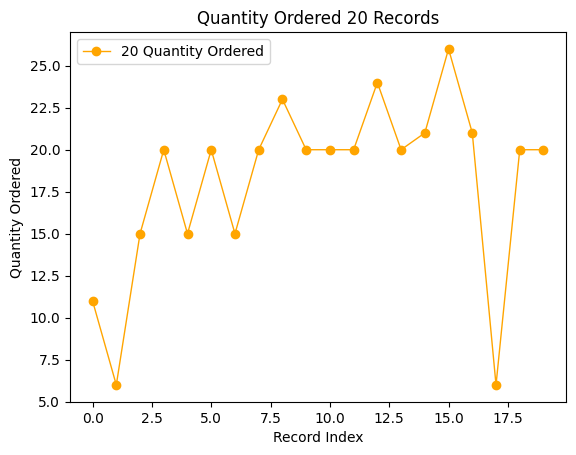

In [79]:

#Display the QUANTITYORDERED of the first 20 records using a line plot.
quantity_ordered=df["QUANTITYORDERED"].head(20)
plt.plot(quantity_ordered,color="orange",linestyle='-',linewidth=1,marker='o',label='20 Quantity Ordered')
plt.title("Quantity Ordered 20 Records")
plt.xlabel("Record Index")
plt.ylabel("Quantity Ordered")
plt.legend()
plt.show()

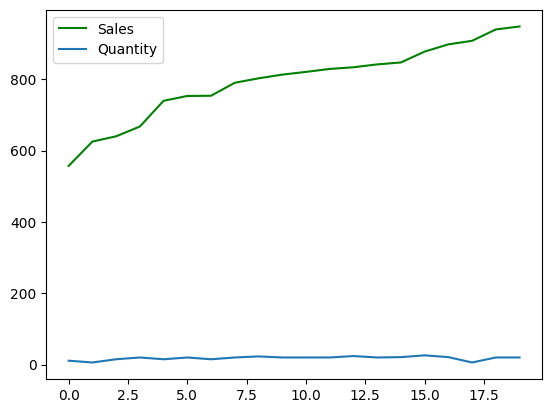

In [80]:
#Line plot for Two columns Together
plt.plot( df["SALES"].head(20),label="Sales",color="green")
plt.plot(df["QUANTITYORDERED"].head(20), label="Quantity")
plt.legend()
plt.show()

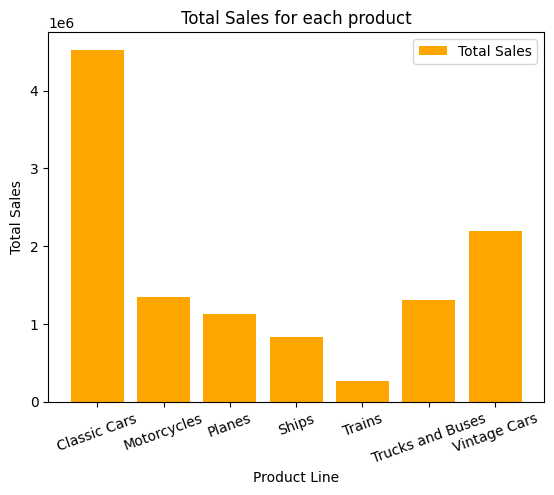

In [81]:
#product Line sales Analysis
#Find the total SALES for each PRODUCTLINE and visualize it using a bar chart.
total_sales=df.groupby("PRODUCTLINE",as_index=True)["SALES"].sum()
plt.bar(total_sales.index,total_sales.values,color="Orange",label="Total Sales")
plt.title("Total Sales for each product")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=20)
plt.show()



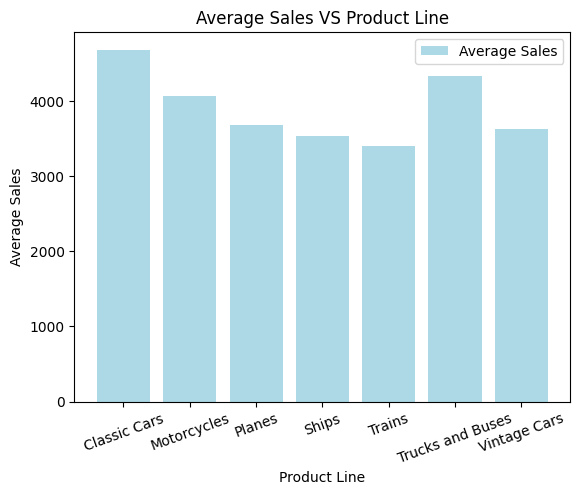

In [82]:
#Find the average SALES for each PRODUCTLINE and visualize it using a bar chart.
avg_sales=df.groupby("PRODUCTLINE")["SALES"].mean()
plt.bar(avg_sales.index,avg_sales.values,color="Lightblue",label="Average Sales")
plt.title("Average Sales VS Product Line")
plt.xlabel("Product Line")
plt.ylabel("Average Sales")
plt.legend()
plt.xticks(rotation=20)
plt.show()

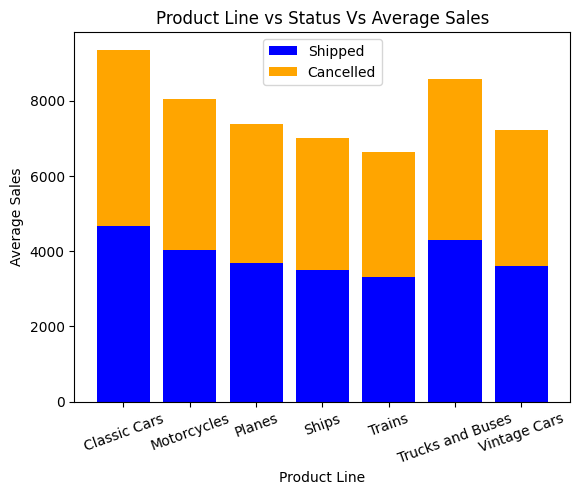

In [83]:
#One new Column Status shows the Product line are shipped or cancelled using Stacked Bars 
shipped=df[df["STATUS"]=="Shipped"].groupby("PRODUCTLINE")["SALES"].mean()
cancelled=df[df["STATUS"]=="Cancelled"].groupby("PRODUCTLINE")["SALES"].mean()

x=np.arange(len(shipped.index))
plt.bar(x,shipped.values,color="Blue",label="Shipped")
plt.bar(x,shipped.values,bottom=shipped.values,color="Orange",label="Cancelled")
plt.title("Product Line vs Status Vs Average Sales")
plt.xlabel("Product Line")
plt.ylabel("Average Sales")
plt.xticks( x, shipped.index, rotation=20)

plt.legend()
plt.show()


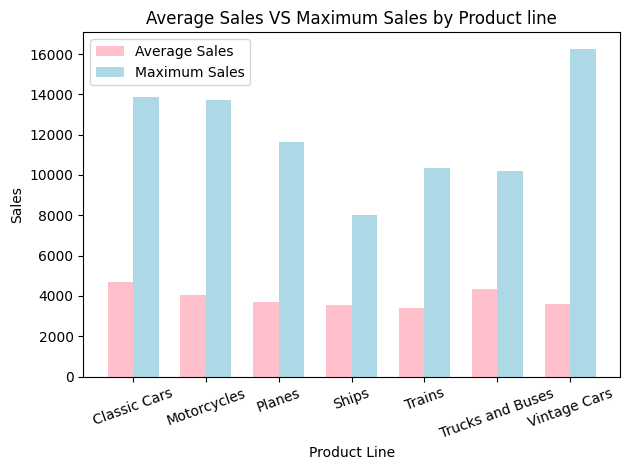

In [84]:
#Average Sales vs Maximum Sales for Each Product Line 
avg_sales=df.groupby("PRODUCTLINE")["SALES"].mean()
max_sales=df.groupby("PRODUCTLINE")["SALES"].max()

x=np.arange(len(avg_sales))
width=0.35

plt.bar(x-width/2,avg_sales.values,width,color="Pink",label="Average Sales")
plt.bar(x+width/2,max_sales.values,width,color="Lightblue",label="Maximum Sales")
plt.xticks(x,avg_sales.index,rotation=20)
plt.title("Average Sales VS Maximum Sales by Product line")
plt.xlabel("Product Line")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

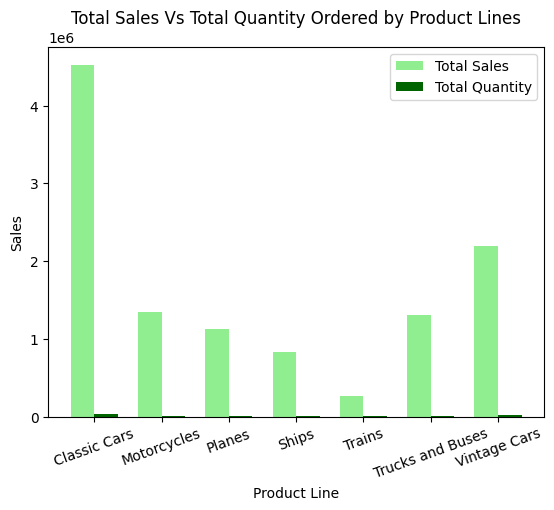

In [85]:
#Compare total SALES and total QUANTITYORDERED for each PRODUCTLINE using a grouped bar chart.
total_sales=df.groupby("PRODUCTLINE")["SALES"].sum()
total_quantity=df.groupby("PRODUCTLINE")["QUANTITYORDERED"].sum()
x=np.arange(len(total_sales))
width=0.35
plt.bar(x-width/2,total_sales.values,width,color="lightgreen",label="Total Sales")
plt.bar(x+width/2,total_quantity.values,width,color="darkgreen",label="Total Quantity")
plt.xticks(x,total_sales.index,rotation=20)
plt.title("Total Sales Vs Total Quantity Ordered by Product Lines")
plt.xlabel("Product Line")
plt.ylabel("Sales")
plt.legend()
plt.show()

#insights-total sales are much larger in numerical value than quantity ordered so quantity bars appear much smaller"

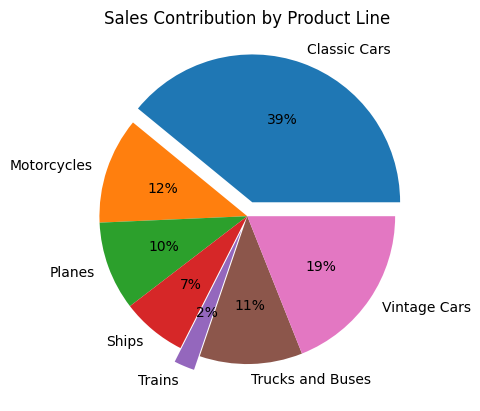

In [86]:
#Show the sales contribution of each PRODUCTLINE using a pie chart with percentages
sales_chart=df.groupby("PRODUCTLINE")["SALES"].sum()
plt.pie(sales_chart.values,labels=sales_chart.index,autopct="%1.0f%%",explode=[0.1,0,0,0,0.1,0,0])
plt.title("Sales Contribution by Product Line")
plt.show()

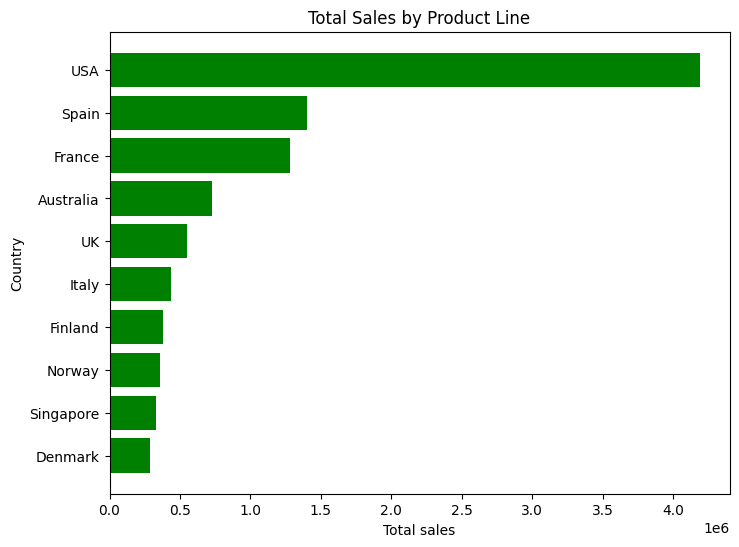

In [87]:

#Country Based Analysis
#Find the top 10 countries based on total SALES and visualize them using a horizontal bar chart.
country_sales=df.groupby("COUNTRY")["SALES"].sum()
top_10=country_sales.sort_values(ascending=False).head(10).sort_values()
plt.figure(figsize=(8,6))
plt.barh(top_10.index,top_10.values,color="green")
plt.title("Total Sales by Product Line")
plt.xlabel("Total sales")
plt.ylabel("Country")
plt.show()

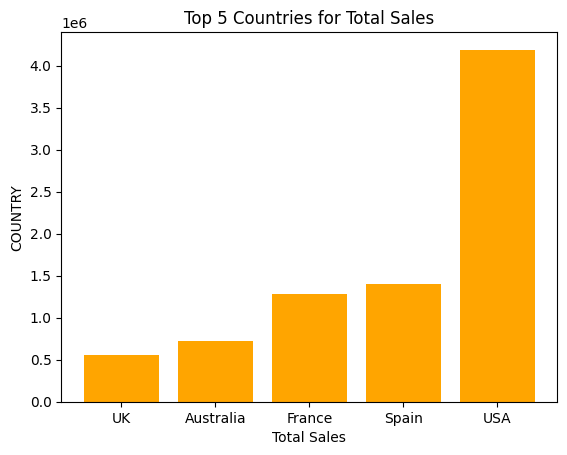

In [88]:
#Top 5 countries based on average Sales Values 
country_sales=df.groupby("COUNTRY")["SALES"].sum()
top_5=country_sales.sort_values(ascending=False).head(5).sort_values()
plt.bar(top_5.index,top_5.values,color="Orange")
plt.title("Top 5 Countries for Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("COUNTRY")
plt.show()

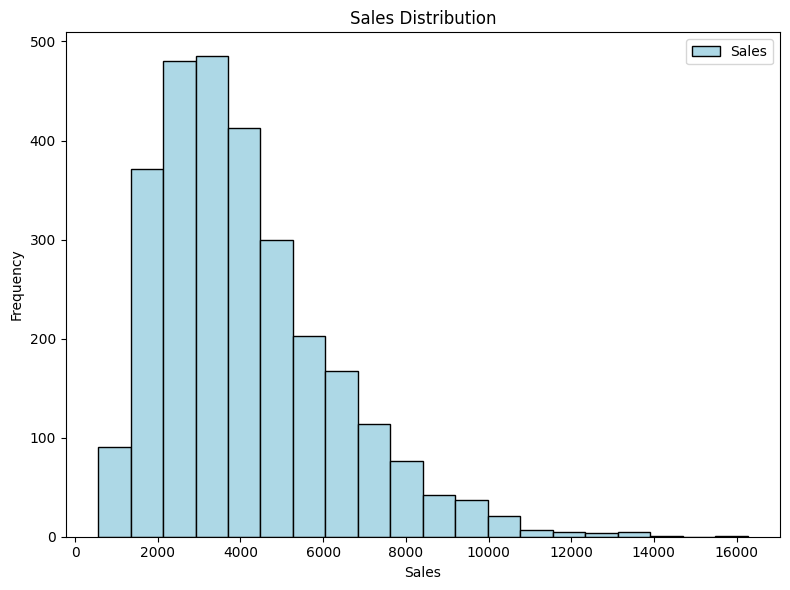

In [94]:
#Create a Histogram distribution for Sales
plt.figure(figsize=(8,5))
plt.hist(df["SALES"],bins=20,label="Sales",color="Lightblue",edgecolor="Black")
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

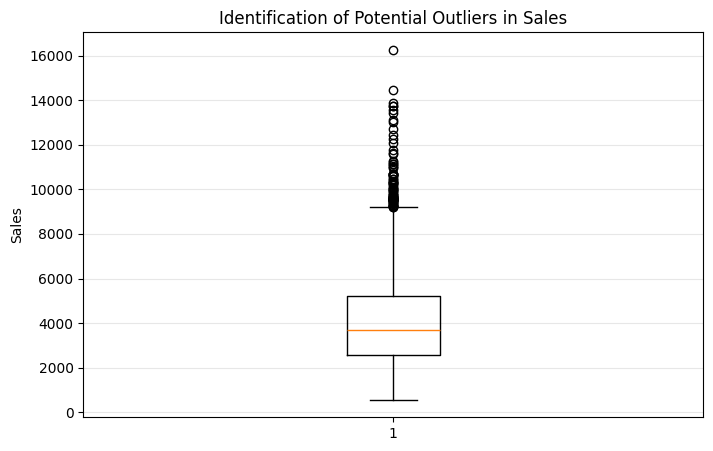

In [90]:
#Create a box plot for SALES and visually identify whether there are potential outliers
plt.figure(figsize=(8,5))
plt.boxplot(df["SALES"],vert=True)
plt.title("Identification of Potential Outliers in Sales")
plt.ylabel("Sales")
plt.grid(axis="y",alpha=0.3)
plt.show()

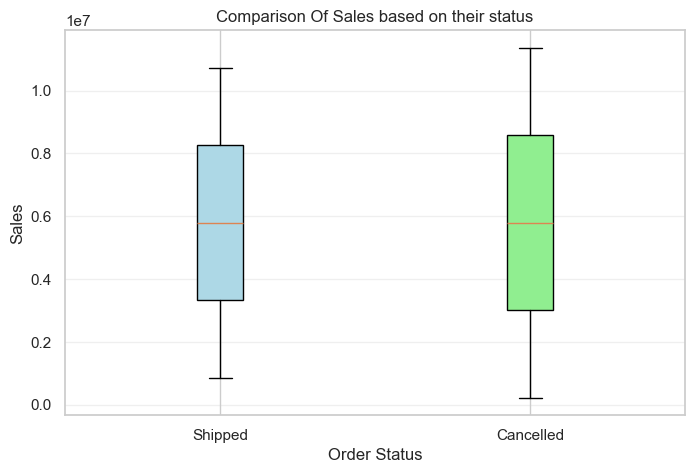

In [54]:
#create box plots to compare the distribution of SALES for two different order statuses
shipped=df.groupby(df["STATUS"]=="Shipped")["SALES"].sum()
cancelled=df.groupby(df["STATUS"]=="Cancelled")["SALES"].sum()

plt.figure(figsize=(8,5))
box=plt.boxplot([shipped,cancelled],patch_artist=True)
box["boxes"][0].set_facecolor("Lightblue")
box["boxes"][1].set_facecolor("lightgreen")
plt.xticks([1, 2], ["Shipped", "Cancelled"])
plt.title("Comparison Of Sales based on their status")
plt.xlabel("Order Status")
plt.ylabel("Sales")
plt.grid(axis="y",alpha=0.3)
plt.show()

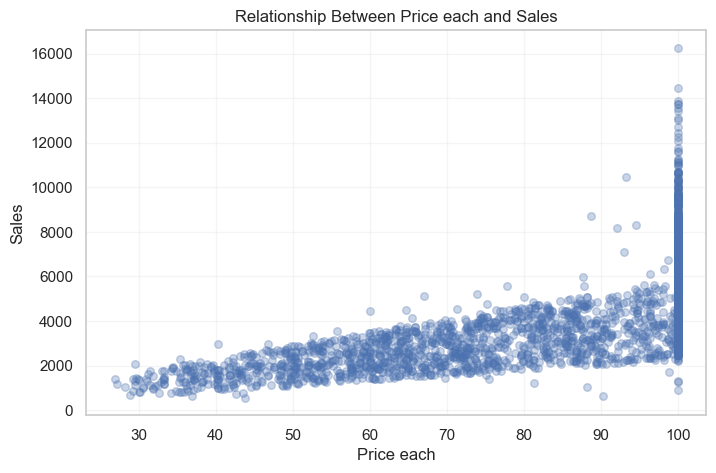

In [55]:
#Create a scatter plot showing relationship between PRICEEACH AND SALES
plt.figure(figsize=(8,5))
plt.scatter(df["PRICEEACH"],df["SALES"], alpha=0.3, s=30)
plt.title("Relationship Between Price each and Sales")
plt.xlabel("Price each")
plt.ylabel("Sales")
plt.grid(alpha=0.2)
plt.show()

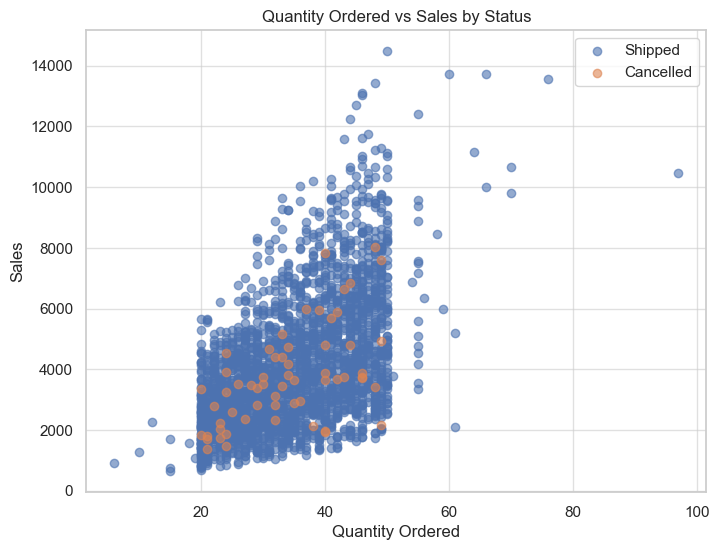

In [56]:
#Separate the data by two STATUS categories and show both groups on the same scatter plot of QUANTITYORDERED vs SALES.
shipped = df[df["STATUS"] == "Shipped"]
cancelled = df[df["STATUS"] == "Cancelled"]

plt.figure(figsize=(8, 6))
plt.scatter(
    shipped["QUANTITYORDERED"],
    shipped["SALES"],
    label="Shipped",
    alpha=0.6
)
plt.scatter(
    cancelled["QUANTITYORDERED"],
    cancelled["SALES"],
    label="Cancelled",
    alpha=0.6
)
plt.title("Quantity Ordered vs Sales by Status")
plt.xlabel("Quantity Ordered")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.6)
plt.show()

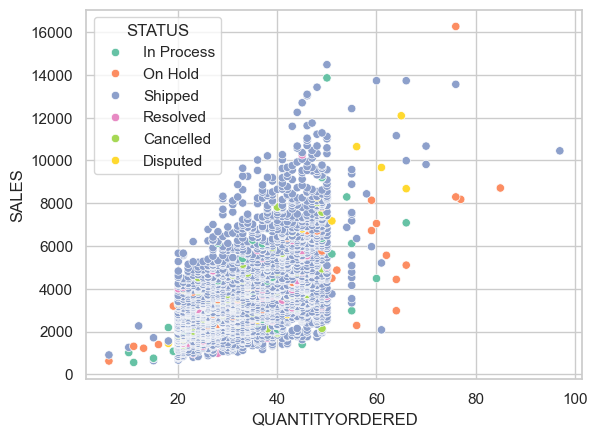

In [57]:
# Visualization using Seaborn 
#Scatter Plot Between Two Numerical values
sns.scatterplot(
    data=df,
    x="QUANTITYORDERED",
    y="SALES",
    hue="STATUS",
    palette="Set2"
)
plt.show()

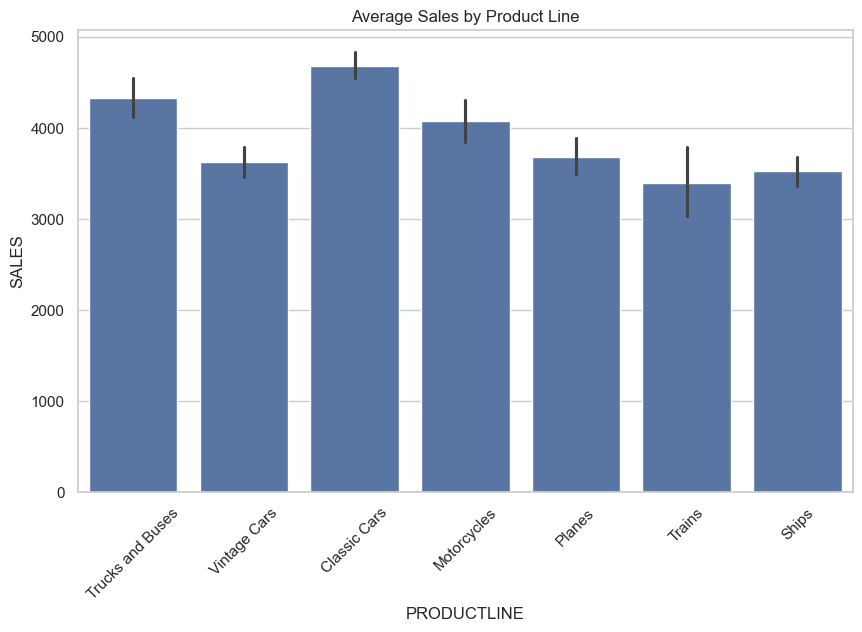

In [58]:
#Based On product Line
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x="PRODUCTLINE",
    y="SALES"
)
plt.title("Average Sales by Product Line")
plt.xticks(rotation=45)

plt.show()

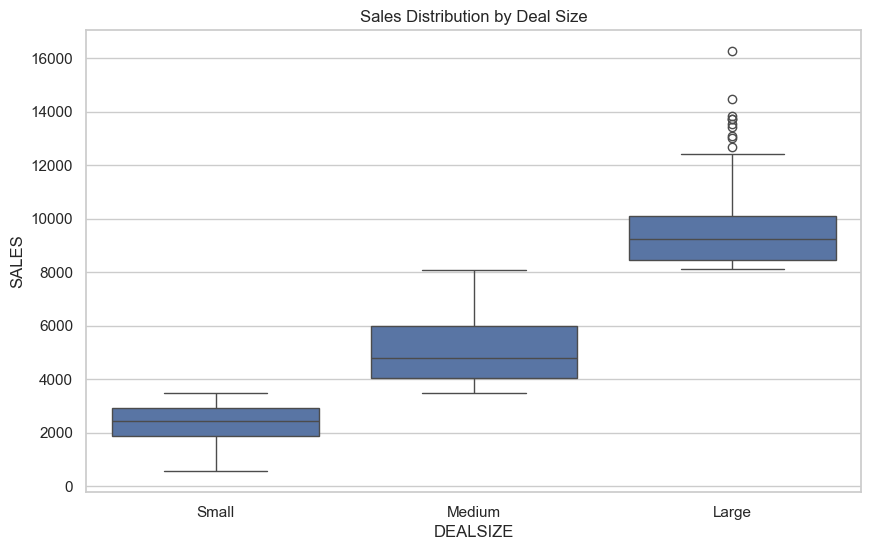

In [74]:
#Sales Contribution By deal size
plt.figure(figsize=(10, 6))
sns.boxplot( data=df, x="DEALSIZE",  y="SALES")
plt.title("Sales Distribution by Deal Size")
plt.show()

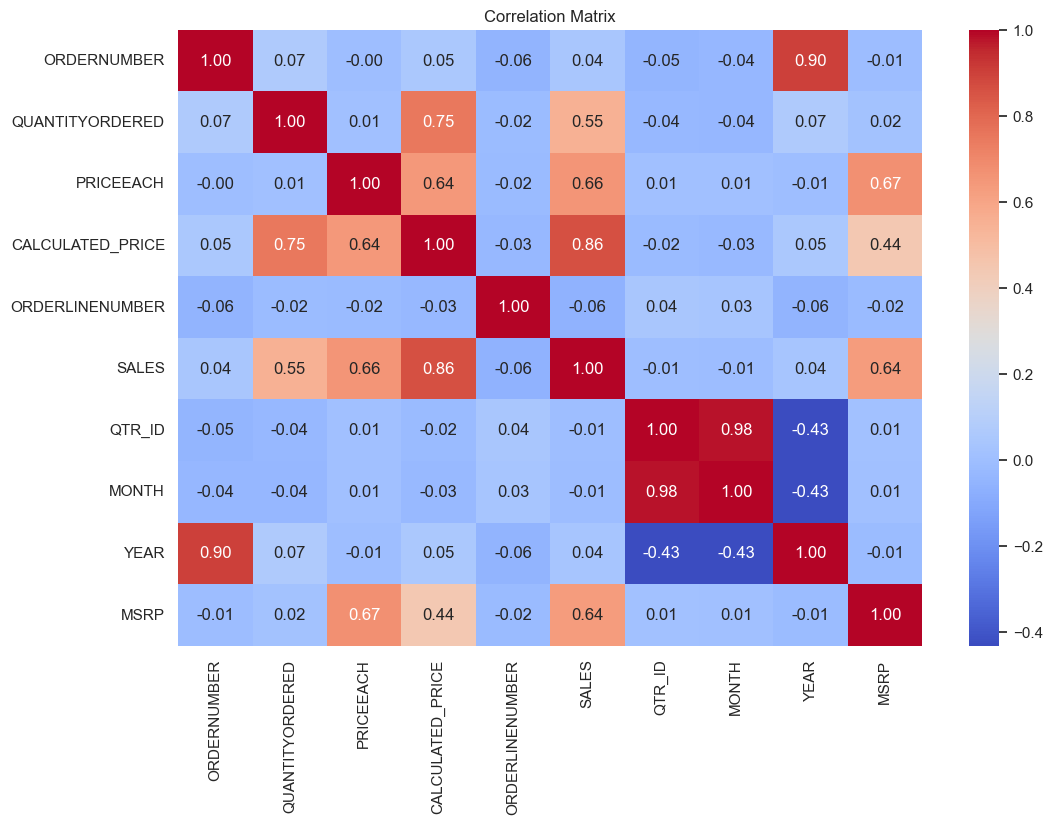

In [75]:
#Correlation
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))

sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

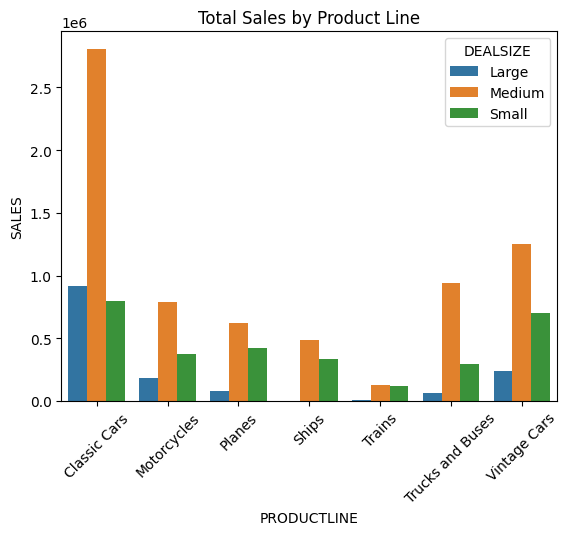

In [103]:
sales = (df.groupby(["PRODUCTLINE","DEALSIZE"])["SALES"].sum().reset_index())
sns.barplot(data=sales,x="PRODUCTLINE",y="SALES",hue="DEALSIZE")
plt.xticks(rotation=45)
plt.title("Total Sales by Product Line")
plt.show()

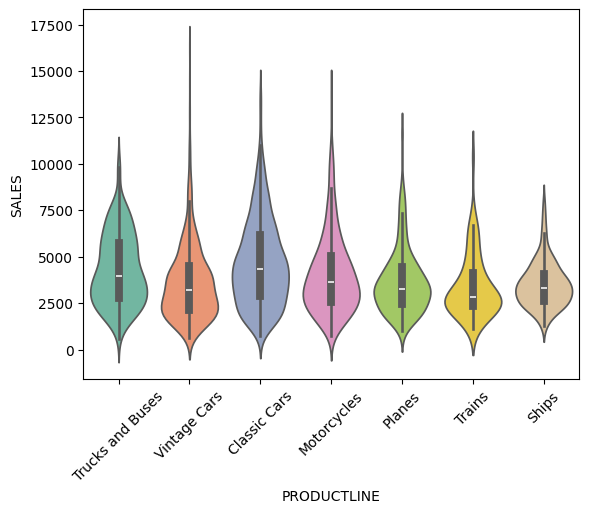

In [115]:
#VIOLIN PLOT ON PRODUCT LINE AND SALES
sns.violinplot( data=df,x="PRODUCTLINE",y="SALES",palette="Set2",hue="PRODUCTLINE",legend=False)
plt.xticks(rotation=45)
plt.show()

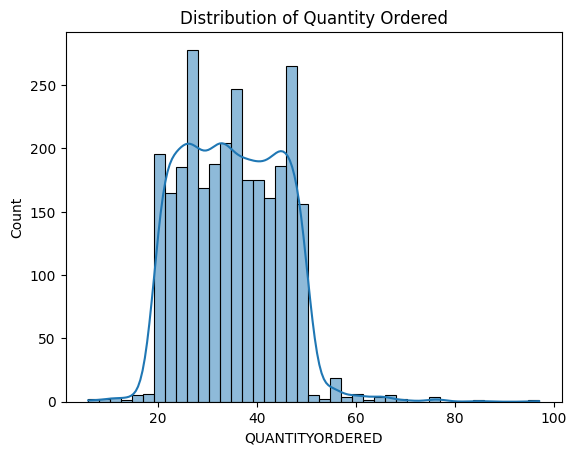

In [11]:
#Kdeplot on Quantity Ordered
sns.histplot( data=df,x="QUANTITYORDERED",kde=True)
plt.title("Distribution of Quantity Ordered")
plt.show()

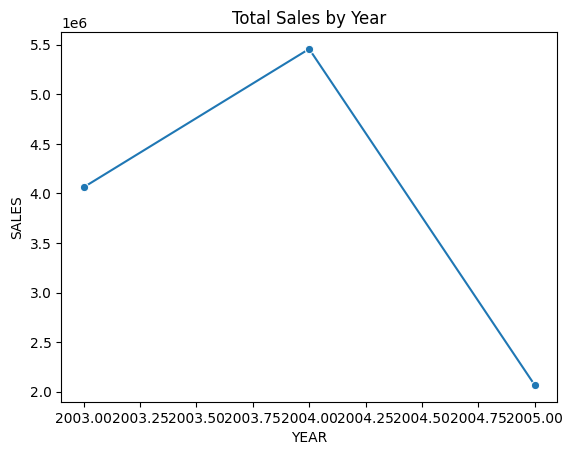

In [14]:
#Total Sales For Each Year
year_sales=df.groupby("YEAR")["SALES"].sum().reset_index()
sns.lineplot( data=year_sales,x="YEAR",y="SALES",marker="o")
plt.title("Total Sales by Year")
plt.show()

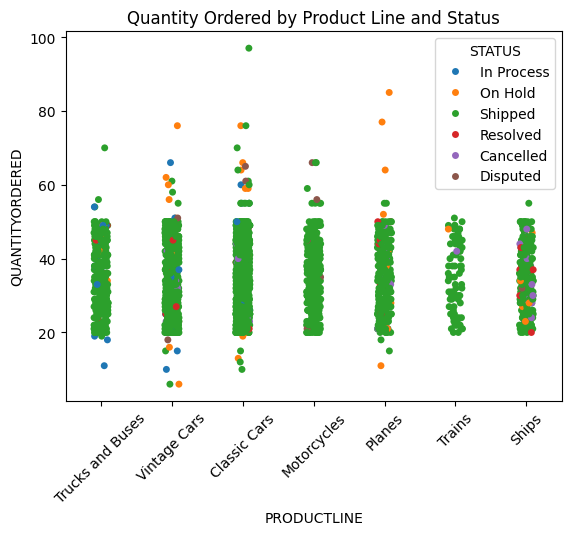

In [24]:
#Strip plot s
sns.stripplot(data=df,x="PRODUCTLINE",y="QUANTITYORDERED",hue="STATUS",jitter=True)
plt.xticks(rotation=45)
plt.title("Quantity Ordered by Product Line and Status")
plt.show()